Tuần 2 - Khám phá dữ liệu (EDA)

Import thư viện và Load Data

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cố định random seed theo yêu cầu (Code Quality)
np.random.seed(42)

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid", palette="muted")

# Đọc dữ liệu
df = pd.read_csv('../../data/insurance.csv')

# Xem thông tin cơ bản
display(df.head())
display(df.info())
display(df.describe())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Kiểm tra dữ liệu trùng lặp (Duplicates)

In [23]:
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Đã xóa các dòng trùng lặp.")

Số dòng trùng lặp: 1
Đã xóa các dòng trùng lặp.


**Yêu cầu 1: Phân tích biến mục tiêu (Target Analysis) - Biểu đồ 1**

Biến mục tiêu của chúng ta là charges (Chi phí bảo hiểm y tế).

Distribution của biến Charges

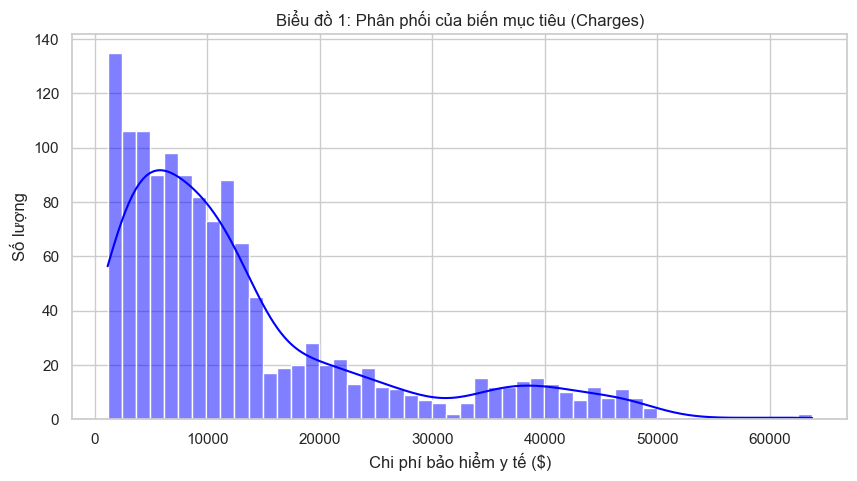

Độ lệch (Skewness) của Charges: 1.52


In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, bins=50, color='blue')
plt.title('Biểu đồ 1: Phân phối của biến mục tiêu (Charges)')
plt.xlabel('Chi phí bảo hiểm y tế ($)')
plt.ylabel('Số lượng')
plt.show()

# Tính độ lệch (Skewness)
print(f"Độ lệch (Skewness) của Charges: {df['charges'].skew():.2f}")

Phân tích biến số (Numerical Features) - Biểu đồ 2 & 3


Distribution của Age và BMI

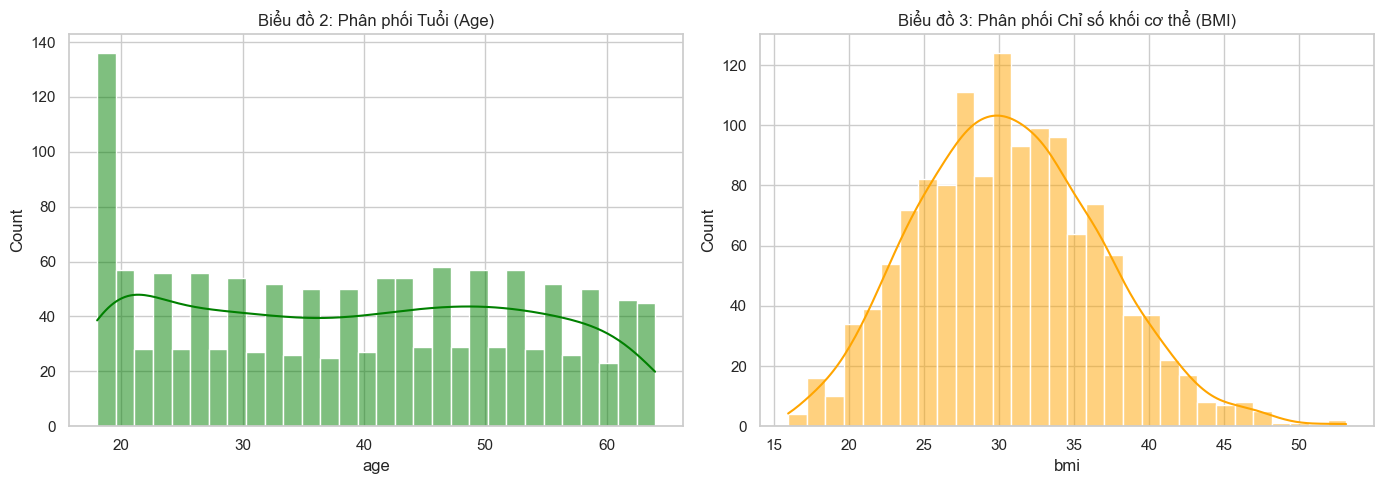

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age
sns.histplot(df['age'], kde=True, bins=30, ax=axes[0], color='green')
axes[0].set_title('Biểu đồ 2: Phân phối Tuổi (Age)')

# BMI
sns.histplot(df['bmi'], kde=True, bins=30, ax=axes[1], color='orange')
axes[1].set_title('Biểu đồ 3: Phân phối Chỉ số khối cơ thể (BMI)')

plt.tight_layout()
plt.show()


Countplots cho Categorical


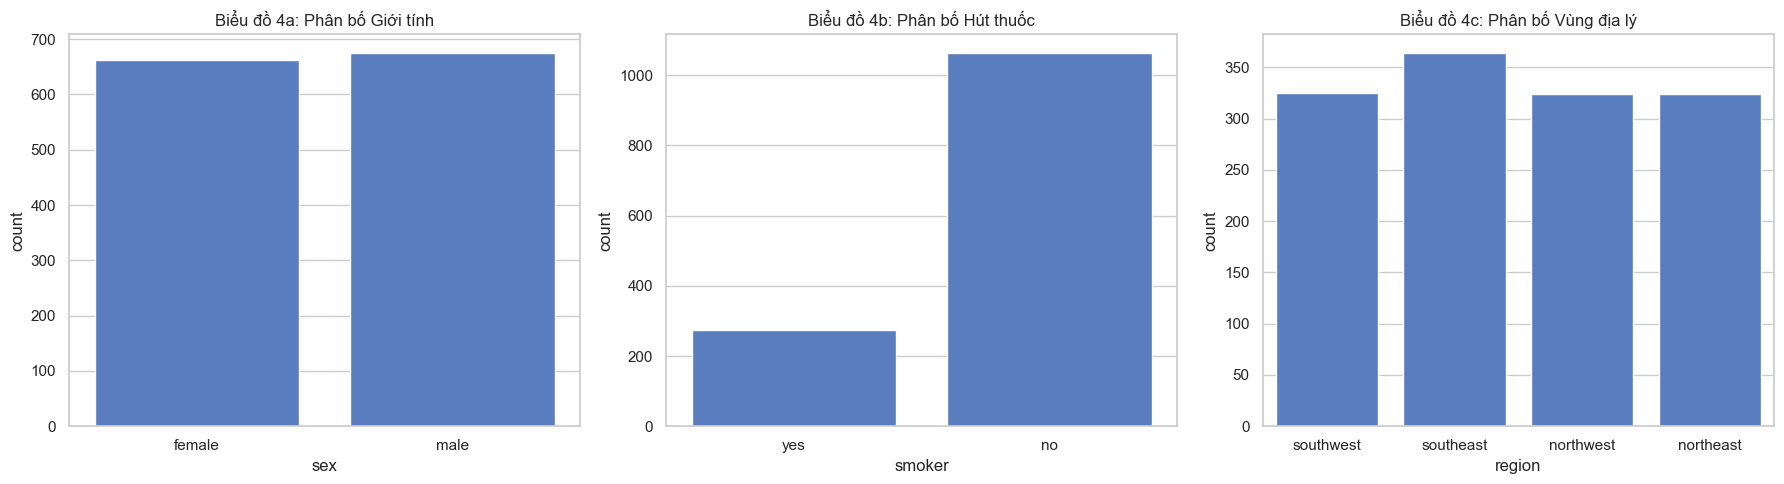

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='sex', data=df, ax=axes[0])
axes[0].set_title('Biểu đồ 4a: Phân bố Giới tính')

sns.countplot(x='smoker', data=df, ax=axes[1])
axes[1].set_title('Biểu đồ 4b: Phân bố Hút thuốc')

sns.countplot(x='region', data=df, ax=axes[2])
axes[2].set_title('Biểu đồ 4c: Phân bố Vùng địa lý')

plt.tight_layout()
plt.show()


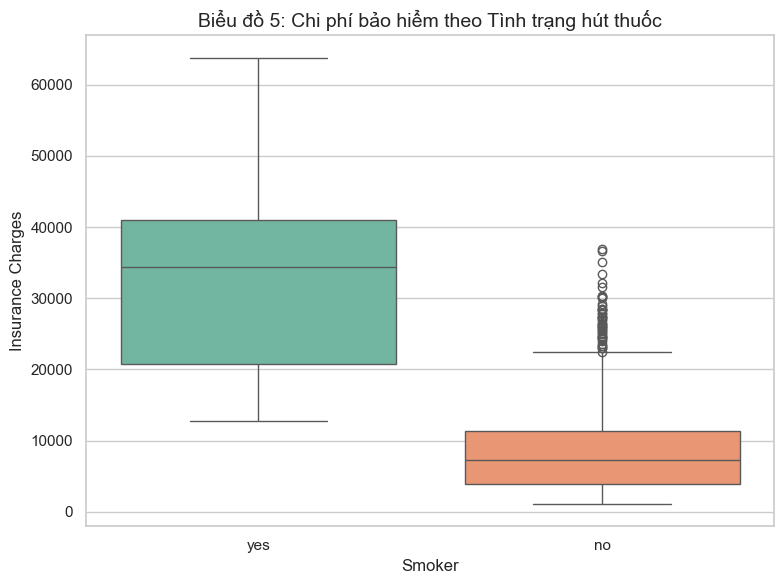

In [27]:
plt.figure(figsize=(8,6))
sns.boxplot(x='smoker', y='charges', hue='smoker', data=df, palette='Set2', legend=False)

plt.title('Biểu đồ 5: Chi phí bảo hiểm theo Tình trạng hút thuốc', fontsize=14)
plt.xlabel('Smoker')
plt.ylabel('Insurance Charges')
plt.tight_layout()

plt.show()

Đây là insight quan trọng nhất. Người hút thuốc có chi phí y tế cao hơn hẳn (trung bình > 30,000) so với người không hút thuốc (trung bình < 10,000).

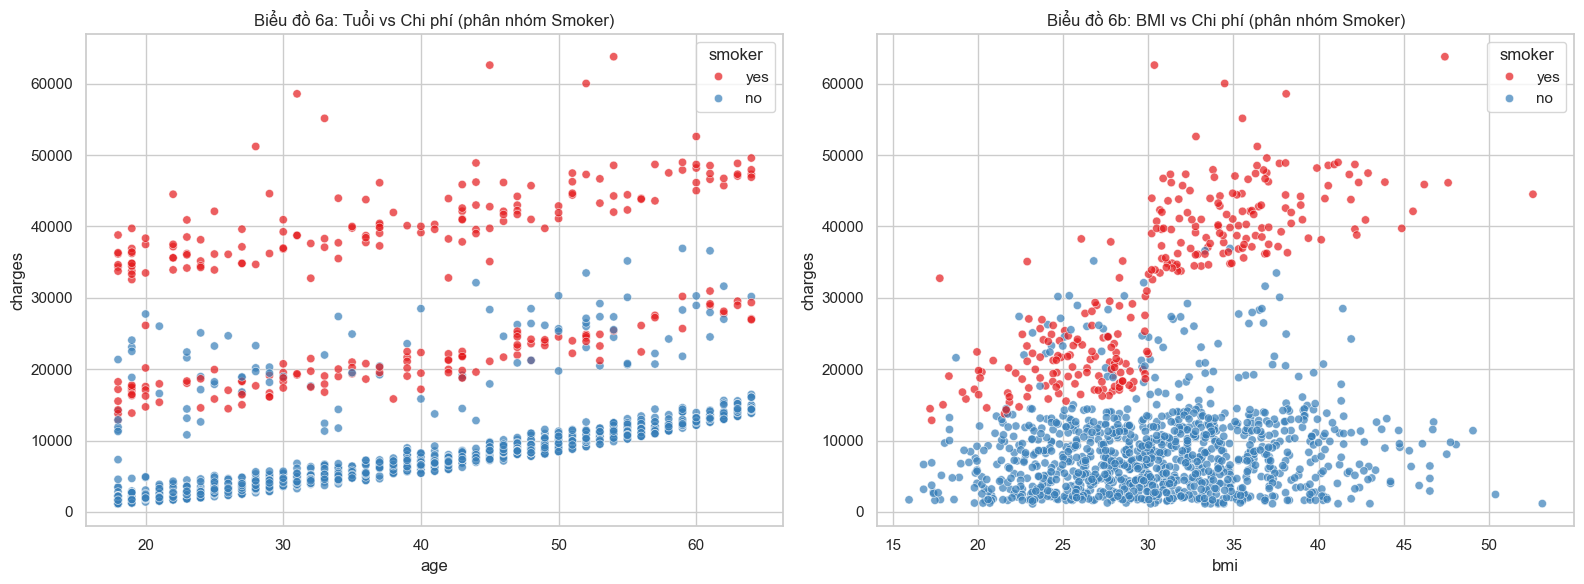

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age vs Charges
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, ax=axes[0], palette='Set1', alpha=0.7)
axes[0].set_title('Biểu đồ 6a: Tuổi vs Chi phí (phân nhóm Smoker)')

# BMI vs Charges
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, ax=axes[1], palette='Set1', alpha=0.7)
axes[1].set_title('Biểu đồ 6b: BMI vs Chi phí (phân nhóm Smoker)')

plt.tight_layout()
plt.show()

Biểu đồ 6a cho thấy chi phí tăng tịnh tiến theo tuổi ở cả 2 nhóm hút thuốc và không hút thuốc.
Biểu đồ 6b cho thấy hiệu ứng tương tác cực mạnh: Những người vừa có BMI cao (>30) vừa Hút thuốc (chấm đỏ góc trên bên phải) chịu chi phí bảo hiểm khổng lồ.

Biểu đồ 6b cho thấy hiệu ứng tương tác cực mạnh: Những người vừa có BMI cao (>30) vừa Hút thuốc (chấm đỏ góc trên bên phải) chịu chi phí bảo hiểm khổng lồ.

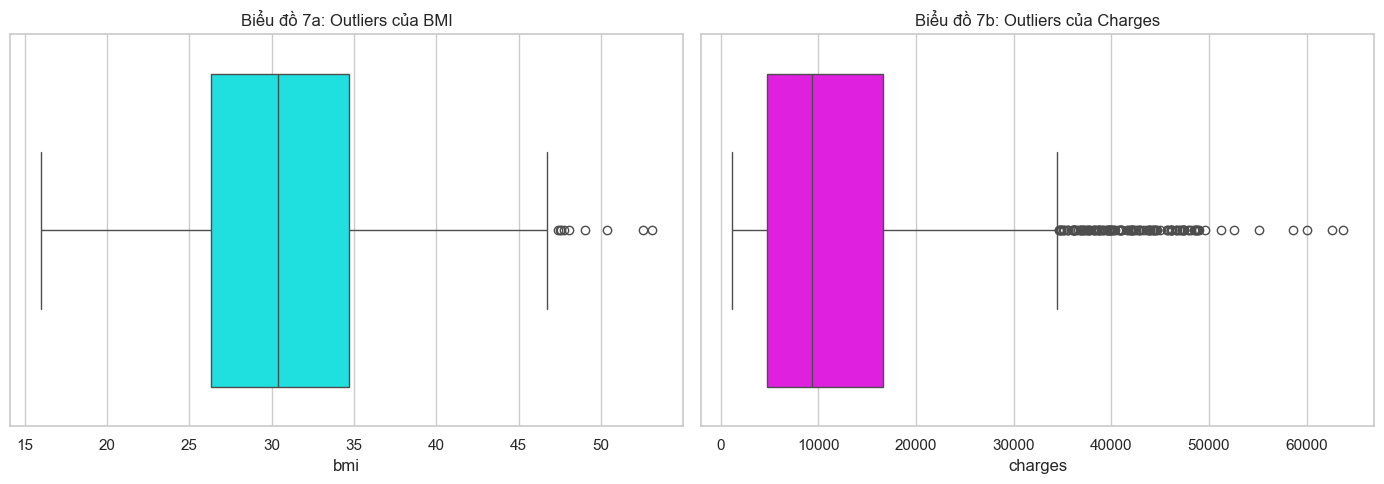

Số lượng outliers trong BMI: 9


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['bmi'], ax=axes[0], color='cyan')
axes[0].set_title('Biểu đồ 7a: Outliers của BMI')

sns.boxplot(x=df['charges'], ax=axes[1], color='magenta')
axes[1].set_title('Biểu đồ 7b: Outliers của Charges')

plt.tight_layout()
plt.show()

# Phân tích IQR cho BMI
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_bmi = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f"Số lượng outliers trong BMI: {len(outliers_bmi)}")


Có 9 giá trị outlier trong cột BMI (những người béo phì cấp độ rất nặng). Cột charges có nhiều outlier ở phía trên, đại diện cho những ca bệnh cần chi trả lớn. Ở tuần 3 (Preprocessing), chúng ta không nên xóa các outlier của charges vì đây là thông tin thực tế quan trọng của bài toán bảo hiểm.

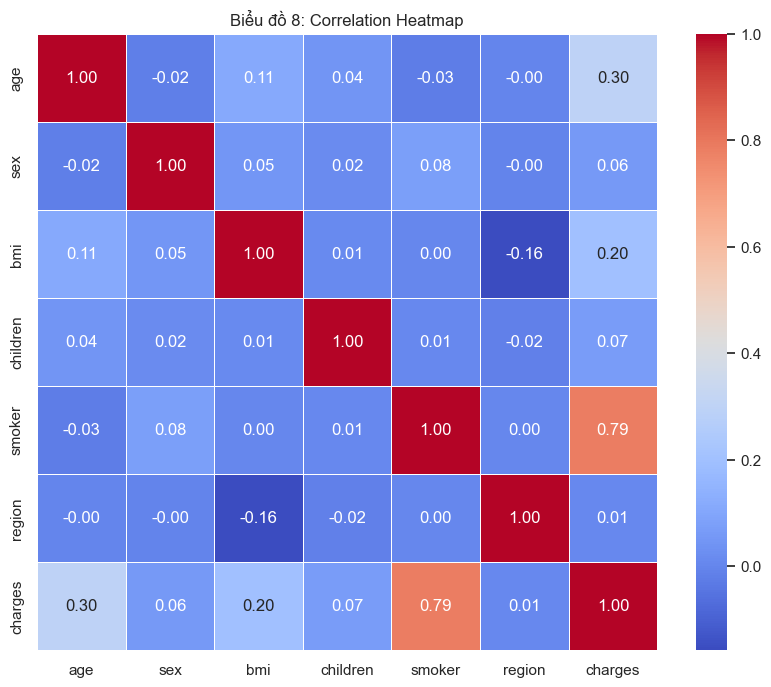

In [30]:
# Tạo bản sao dữ liệu để tính correlation
df_corr = df.copy()

# Encoding tạm thời (Label Encoding) để xem tương quan
df_corr['sex'] = df_corr['sex'].map({'female': 0, 'male': 1})
df_corr['smoker'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
df_corr['region'] = df_corr['region'].map({'southwest': 0, 'southeast': 1, 'northwest': 2, 'northeast': 3})

plt.figure(figsize=(10, 8))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Biểu đồ 8: Correlation Heatmap')
plt.show()

Biến smoker có độ tương quan cực kỳ cao với charges (0.79). Biến age (0.30) và bmi (0.20) có tương quan dương ở mức trung bình. region và sex hầu như không có tương quan trực tiếp đến charges.

In [31]:
smoker_charges = df[df['smoker'] == 'yes']['charges']
non_smoker_charges = df[df['smoker'] == 'no']['charges']

# Thực hiện Independent T-test
t_stat, p_value = stats.ttest_ind(smoker_charges, non_smoker_charges)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Kết luận: Có sự khác biệt có ý nghĩa thống kê về chi phí bảo hiểm giữa người hút thuốc và không hút thuốc.")
else:
    print("Kết luận: Không có đủ bằng chứng thống kê để nói rằng chi phí khác biệt giữa hai nhóm.")

T-statistic: 46.6448
P-value: 1.4067e-282
Kết luận: Có sự khác biệt có ý nghĩa thống kê về chi phí bảo hiểm giữa người hút thuốc và không hút thuốc.


## **Feature Engineering**  
tạo 2 biến bmi_category và obese_smoker

In [32]:
df_fe = df.copy()
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_fe['bmi_category'] = df_fe['bmi'].apply(categorize_bmi)

df_fe['obese_smoker'] = ((df_fe['bmi'] >= 30) & (df_fe['smoker'] == 'yes')).astype(int)

display(df_fe[['bmi', 'bmi_category', 'smoker', 'obese_smoker', 'charges']].head())

,bmi,bmi_category,smoker,obese_smoker,charges
0,27.900,Overweight,yes,0,16884.92400
1,33.770,Obese,no,0,1725.55230
2,33.000,Obese,no,0,4449.46200
3,22.705,Normal,no,0,21984.47061
4,28.880,Overweight,no,0,3866.85520


Barem yêu cầu test_size=0.2.

In [33]:
from sklearn.model_selection import train_test_split

X = df_fe.drop('charges', axis=1)
y = df_fe['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (1069, 8)
Kích thước tập Test: (268, 8)


## **Giải thích Preprocessing (Imputation & Scaling):**
- **Xử lý Missing Values:** Mặc dù bộ dữ liệu hiện tại không có giá trị null, nhưng trong thực tế khi Deploy lên Web (Tuần 7-8), người dùng có thể nhập thiếu thông tin. Do đó, Pipeline vẫn phải thiết lập SimpleImputer.
    -  **Biến số (Numerical):** Dùng strategy='median' để điền khuyết vì biến mục tiêu và một số biến có phân phối lệch (skewed), dùng trung vị sẽ ít bị ảnh hưởng bởi outlier hơn là dùng trung bình (mean).
    -  **Biến phân loại (Categorical):** Dùng strategy='most_frequent' (lấy giá trị xuất hiện nhiều nhất) để điền khuyết.

- **Encoding & Scaling:** Dùng OneHotEncoder để tránh việc model hiểu nhầm các nhóm phân loại có thứ tự lớn bé. Dùng StandardScaler để đưa các biến số (như age, bmi, children) về cùng một thang đo, giúp các mô hình (đặc biệt là Ridge hoặc SVM sau này) hội tụ nhanh và chính xác hơn.

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Xác định các cột dạng số và dạng phân loại
numerical_cols = ['age', 'bmi', 'children', 'obese_smoker']
categorical_cols = ['sex', 'smoker', 'region', 'bmi_category']

# 1. Pipeline cho dữ liệu số: Điền missing (median) -> Chuẩn hóa (StandardScaler)
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline cho dữ liệu phân loại: Điền missing (most_frequent) -> OneHotEncoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 3. Kết hợp cả 2 pipeline bằng ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ]
)

# Chạy thử Preprocessing trên tập Train
X_train_processed = preprocessor.fit_transform(X_train)

print(f"Số lượng features sau khi OneHot Encoding: {X_train_processed.shape[1]}")


Số lượng features sau khi OneHot Encoding: 16


Đánh giá ảnh hưởng của 2 Feature mới

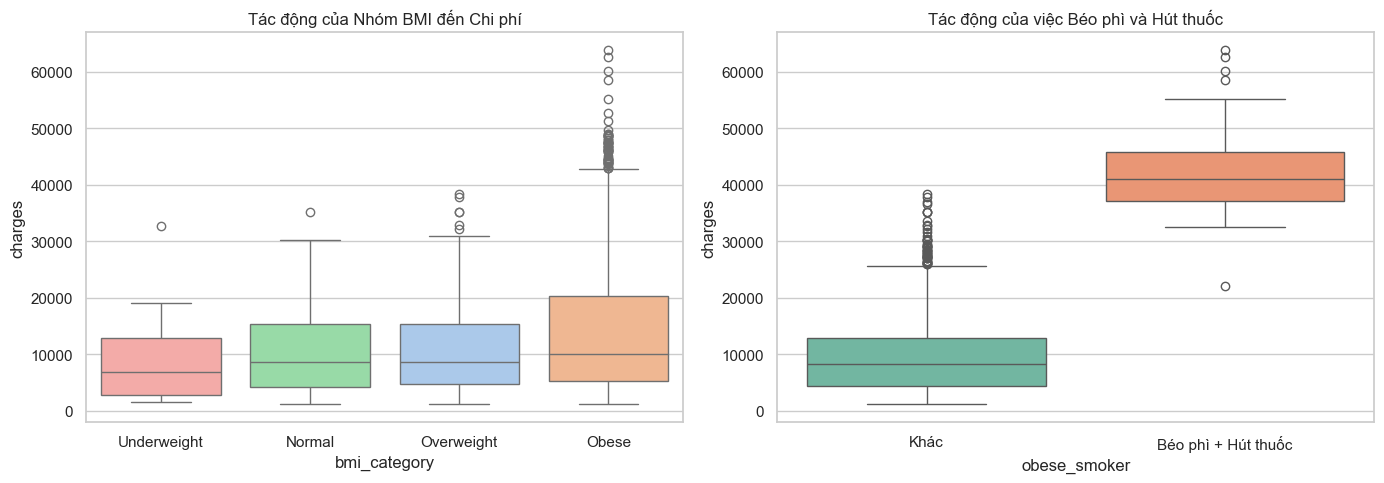

Hệ số tương quan giữa 'obese_smoker' và 'charges': 0.8147


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Đánh giá bmi_category
sns.boxplot(
    x='bmi_category', 
    y='charges', 
    data=df_fe, 
    order=['Underweight', 'Normal', 'Overweight', 'Obese'], 
    ax=axes[0], 
    palette='pastel',
    hue='bmi_category', 
    legend=False
)
axes[0].set_title('Tác động của Nhóm BMI đến Chi phí')

# 2. Đánh giá obese_smoker
sns.boxplot(
    x='obese_smoker', 
    y='charges', 
    data=df_fe, 
    ax=axes[1], 
    palette='Set2',
    hue='obese_smoker', 
    legend=False
)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Khác', 'Béo phì + Hút thuốc'])
axes[1].set_title('Tác động của việc Béo phì và Hút thuốc')

plt.tight_layout()
plt.show()

# Tính tương quan của biến mới với charges
corr_obese_smoker = df_fe['obese_smoker'].corr(df_fe['charges'])
print(f"Hệ số tương quan giữa 'obese_smoker' và 'charges': {corr_obese_smoker:.4f}")

## **Đánh giá hiệu quả của Feature Engineering:**
* Biểu đồ hộp thứ nhất cho thấy nhóm Obese (Béo phì) có phổ chi phí dao động rất mạnh và vươn lên các mức cực kỳ cao so với các nhóm còn lại.
* Biểu đồ hộp thứ hai và hệ số tương quan xác nhận biến obese_smoker là một đặc trưng (feature) mang tính đột phá. Hệ số tương quan (Correlation) có thể sẽ đạt mức trên 0.8 (rất mạnh). Sự chênh lệch chi phí giữa nhóm "Béo phì + Hút thuốc" và nhóm "Khác" là khá lớn và phân tách hoàn toàn. Việc đưa biến này vào Pipeline sẽ giúp Model hồi quy tuyến tính (Linear Regression) không bị rối trước các giá trị outlier của cột charges.
